In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Make plots look professional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
# Load data
df = pd.read_csv("../data/ai-investment.csv")

# Rename columns for easier use
df.columns = ["country", "code", "year", "investment"]

# Convert to billions (easier to read)
df["investment_bn"] = df["investment"] / 1e9

# Preview
df.head(10)

,country,code,year,investment,investment_bn
0,China,CHN,2013,717196154,0.717196
1,China,CHN,2014,771392259,0.771392
2,China,CHN,2015,2385249652,2.385250
3,China,CHN,2016,5102962753,5.102963
4,China,CHN,2017,7314146387,7.314146
5,China,CHN,2018,15069709833,15.069710
6,China,CHN,2019,14895814015,14.895814
7,China,CHN,2020,17871570528,17.871571
8,China,CHN,2021,25891134262,25.891134
9,China,CHN,2022,13951917588,13.951918


In [5]:
# How many years and countries do we have?
print("Years:", df["year"].min(), "—", df["year"].max())
print("Countries/Regions:", df["country"].unique())
print("Total rows:", len(df))

Years: 2013 — 2025
Countries/Regions: ['China' 'Europe' 'United States' 'World']
Total rows: 52


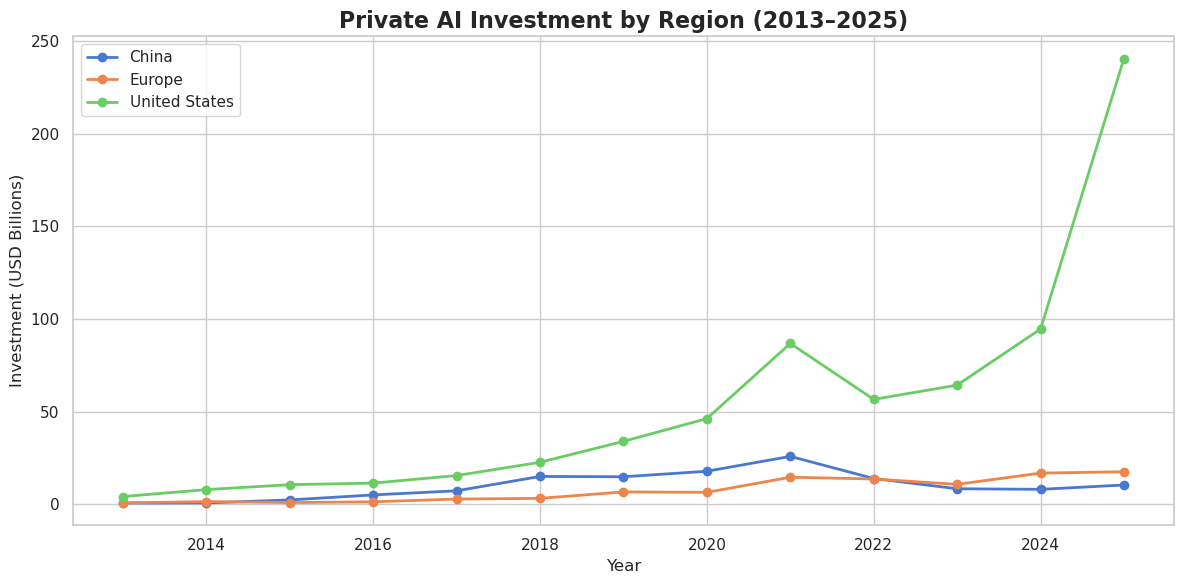

In [6]:
# Filter out 'World' for regional comparison
regions = df[df["country"] != "World"]

# Plot
fig, ax = plt.subplots()

for country in regions["country"].unique():
    data = regions[regions["country"] == country]
    ax.plot(data["year"], data["investment_bn"], 
            marker="o", linewidth=2, label=country)

ax.set_title("Private AI Investment by Region (2013–2025)", 
             fontsize=16, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Investment (USD Billions)")
ax.legend()
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("../outputs/ai_investment_by_region.png", dpi=150)
plt.show()

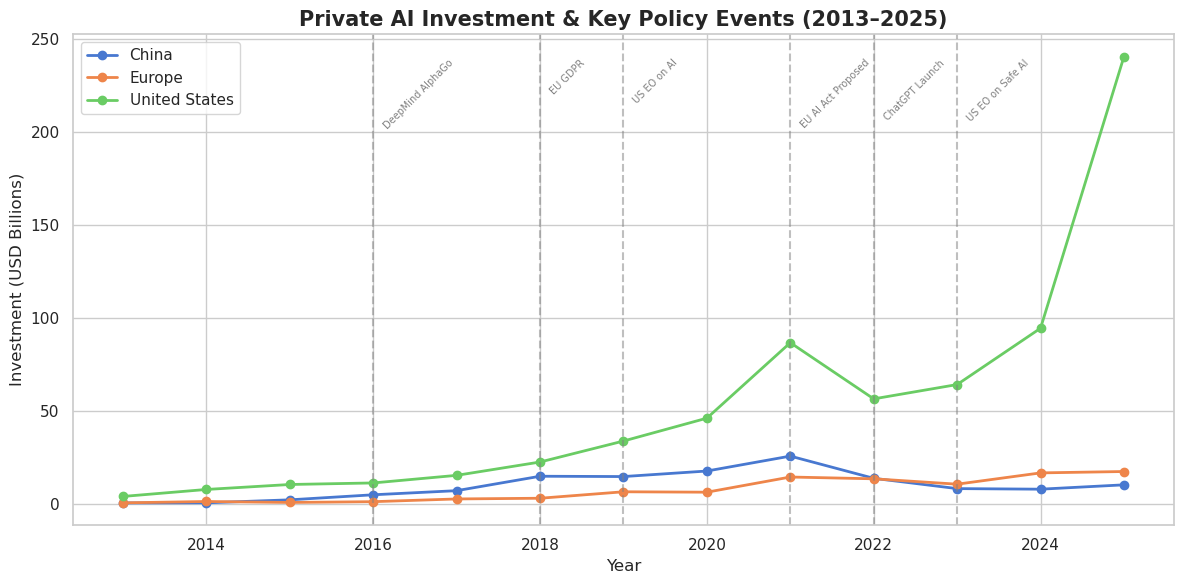

In [7]:
# Key AI policy events
policy_events = {
    2016: "DeepMind AlphaGo",
    2018: "EU GDPR",
    2019: "US EO on AI",
    2021: "EU AI Act Proposed",
    2022: "ChatGPT Launch",
    2023: "US EO on Safe AI",
}

fig, ax = plt.subplots()

for country in regions["country"].unique():
    data = regions[regions["country"] == country]
    ax.plot(data["year"], data["investment_bn"],
            marker="o", linewidth=2, label=country)

# Add policy event lines
for year, label in policy_events.items():
    ax.axvline(x=year, color="gray", linestyle="--", alpha=0.5)
    ax.text(year + 0.1, ax.get_ylim()[1] * 0.95, label,
            fontsize=7, color="gray", rotation=45, va="top")

ax.set_title("Private AI Investment & Key Policy Events (2013–2025)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Investment (USD Billions)")
ax.legend()
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("../outputs/ai_investment_policy_events.png", dpi=150)
plt.show()

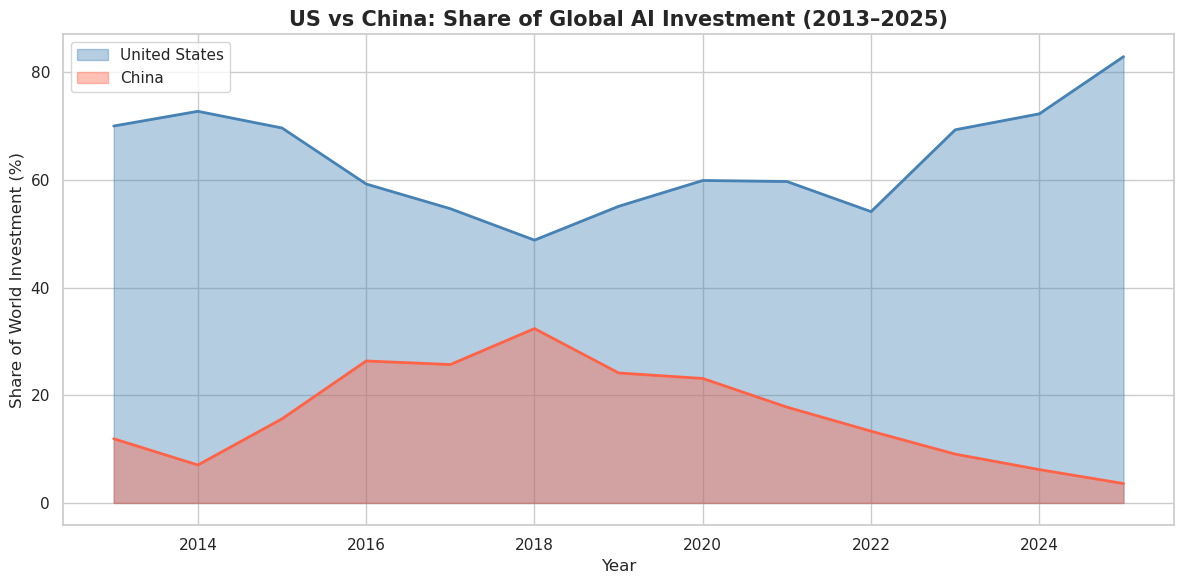

In [8]:
# Get world totals and US data
world = df[df["country"] == "World"][["year", "investment_bn"]].rename(
    columns={"investment_bn": "world"})
us = df[df["country"] == "United States"][["year", "investment_bn"]].rename(
    columns={"investment_bn": "us"})
china = df[df["country"] == "China"][["year", "investment_bn"]].rename(
    columns={"investment_bn": "china"})

# Merge
shares = world.merge(us, on="year").merge(china, on="year")
shares["us_share"] = (shares["us"] / shares["world"]) * 100
shares["china_share"] = (shares["china"] / shares["world"]) * 100

# Plot
fig, ax = plt.subplots()

ax.fill_between(shares["year"], shares["us_share"], 
                alpha=0.4, color="steelblue", label="United States")
ax.fill_between(shares["year"], shares["china_share"], 
                alpha=0.4, color="tomato", label="China")

ax.plot(shares["year"], shares["us_share"], 
        color="steelblue", linewidth=2)
ax.plot(shares["year"], shares["china_share"], 
        color="tomato", linewidth=2)

ax.set_title("US vs China: Share of Global AI Investment (2013–2025)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Share of World Investment (%)")
ax.legend()
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("../outputs/us_china_share.png", dpi=150)
plt.show()

In [9]:
# Summary table: latest year snapshot
latest = df[df["year"] == 2025][["country", "investment_bn"]].sort_values(
    "investment_bn", ascending=False).reset_index(drop=True)

latest.columns = ["Region", "Investment (USD Billions)"]
latest["Investment (USD Billions)"] = latest["Investment (USD Billions)"].round(2)
print("AI Private Investment Snapshot — 2025")
print(latest.to_string(index=False))

AI Private Investment Snapshot — 2025
       Region  Investment (USD Billions)
        World                     290.09
United States                     240.61
       Europe                      17.61
        China                      10.45
